# TRTD Final Leakage-Free Pipeline — Complete Results for Paper §5

**Purpose.** Implement every open item from §5.5 of the results write-up, on top of the multi-dataset Colab pipeline:

| RQ / metric | Implementation in this notebook |
|---|---|
| RQ1 temporal residual vs distance-only | Ablation `use_temporal=True/False` |
| RQ2 recovery latency | From per-round MCC history (rounds to 95% pre-drift) |
| RQ3 adaptive θ vs fixed θ + false isolation | Ablation `use_adaptive_theta`; FIR on benign sessions |
| RQ4 low-rank vs full-rank | Rank = full dense vs capped low-rank |
| RQ5 stealth / residual | Stealth regime + Full vs Distance-only gap |
| Trust ECE | Per-session τ logged; bin-wise ECE |
| Policy stability | Session-level decision transitions |
| Privacy–utility | Sweep `dp_sigma` ∈ {0, 0.05, 0.15, 0.3, 0.5} |
| Statistical tests | Wilcoxon + Friedman on matched (dataset × drift) |

**Leakage-free rules (enforced):**
1. Scaler fit only on warm-up **benign-heavy** windows (same as main pipeline).
2. Verifier calibration only on **benign-only** silent rounds before scoring.
3. Cross-domain adapted normalization uses **assumed-benign** target samples only; federated `P` stays frozen from source.
4. Per-session labels for ECE/FIR never used to update `P`, θ, or baselines during the scored rounds.
5. No attack labels enter feature selection, scaling, or rank choice.

**How to run.**
1. Execute `TRTD_Multi_Dataset_Colab_v3` through Section 11 in the same runtime (so `loaded`, `run_trtd_experiment`, `CONFIG`, geometry classes exist).
2. Run this notebook top-to-bottom.
3. Artefacts → `/content/trtd_final_figures` (or `./trtd_final_figures`).

## 0. Imports, style, dependency check

In [1]:
import os, time, warnings, copy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef, f1_score
from scipy import stats

mpl.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 300, 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11, 'legend.fontsize': 9,
    'axes.grid': True, 'grid.alpha': 0.3,
})

FIG_DIR = '/content/trtd_final_figures' if os.path.isdir('/content') else './trtd_final_figures'
os.makedirs(FIG_DIR, exist_ok=True)

HAS_LOADED = 'loaded' in dir() and isinstance(loaded, dict) and len(loaded) > 0
HAS_RUNNER = 'run_trtd_experiment' in dir()
HAS_CLASSES = all(x in dir() for x in ['TRTDClient', 'TRTDServer', 'TRTDVerifier', 'RDPAccountant',
                                         'build_scenario_pools', 'sample_real_window', 'ensure_spd'])
print(f'FIG_DIR={FIG_DIR}')
print(f'loaded={HAS_LOADED}  runner={HAS_RUNNER}  geometry_classes={HAS_CLASSES}')
if not (HAS_LOADED and HAS_RUNNER and HAS_CLASSES):
    print('WARNING: Run main Colab pipeline (Sections 0–11) in this kernel first.')
    print('Sections that need live data will skip; structure/demo still runs.')

FIG_DIR=/content/trtd_final_figures
loaded=False  runner=False  geometry_classes=False
Sections that need live data will skip; structure/demo still runs.


## 1. Instrumented leakage-free experiment runner

Wraps the same geometry as the main pipeline but **logs every session** `(τ, decision, y_true, D_t, R_t)` so we can compute:
- true **false-isolation rate** on benign sessions only
- **ECE** of trust score τ
- **policy transitions** at session level
- **recovery latency** from per-round MCC

No scored-round labels update `P`, scaler, or verifier baseline.

In [2]:
def run_trtd_instrumented(
    df, feature_cols, drift_type='abrupt',
    n_clients=10, n_rounds=24, window=80, rank=6, seed=42,
    use_temporal=True, use_adaptive_theta=True, use_dp=True,
    dp_sigma=0.15, dp_clip=1.0, alpha=2.0, beta=2.5,
    full_rank=False, verbose=False,
):
    """Leakage-free TRTD run with per-session logs.

    full_rank=True → transmit/aggregate dense tangent (no rank truncation) for RQ4.
    """
    d = len(feature_cols)
    if full_rank:
        rank = d  # keep all eigenpairs → dense reconstruction
    else:
        rank = max(2, min(rank, (d - 1) // 2))

    rng = np.random.RandomState(seed)
    normal_pool, attack_pools, client_cat = build_scenario_pools(df, n_clients, seed=seed)

    clients = [TRTDClient(k, d, rank=rank, clip_C=dp_clip,
                          noise_sigma=dp_sigma if use_dp else 0.0) for k in range(n_clients)]
    server = TRTDServer(d, theta0=0.55, eta=0.12 if use_adaptive_theta else 0.0)
    verifier = TRTDVerifier(alpha=alpha, beta=beta if use_temporal else 0.0,
                            gamma=0.4, delta=0.1)
    accountant = RDPAccountant()

    history = defaultdict(list)
    session_U_prev = {}
    # Per-session logs (leakage-free: only for metrics, never for training)
    all_tau, all_y, all_pred, all_decision, all_D, all_R = [], [], [], [], [], []
    pooled_true, pooled_pred = [], []

    # ---- Warm-up: fit scalers on early clean windows only ----
    n_warm = min(3, n_rounds)
    for t in range(n_warm):
        for k in range(n_clients):
            X, _ = sample_real_window(k, 0, n_rounds, 'none', normal_pool, attack_pools,
                                      client_cat, window, rng, feature_cols)
            clients[k].fit_scaler(X)

    # ---- Calibration: benign-only silent rounds (no attacks in windows) ----
    cal_D, cal_R = [], []
    for t in range(n_warm):
        client_factors, weights, Xy = [], [], {}
        for k in range(n_clients):
            X, y = sample_real_window(k, 0, n_rounds, 'none', normal_pool, attack_pools,
                                      client_cat, window, rng, feature_cols)
            Xy[k] = (X, y)
            Lr, Vr, _ = clients[k].compute_private_tangent(X, server.P)
            client_factors.append((Lr, Vr))
            weights.append(len(X))
            if use_dp:
                accountant.add_round(max(dp_sigma, 1e-6))
        weights = np.asarray(weights, dtype=float); weights /= weights.sum()
        server.aggregate_and_update(client_factors, weights)
        for k in range(n_clients):
            X, y = Xy[k]
            S_t = clients[k].construct_covariance(X)
            U_prev = session_U_prev.get(k, np.zeros((d, d)))
            res = verifier.verify(S_t, U_prev, server.P, server.P_prev, server.V, server.theta,
                                  adapt=False)
            session_U_prev[k] = res['U_t']
            cal_D.append(res['D_t']); cal_R.append(res['R_t'])
    verifier.calibrate(cal_D, cal_R)

    # ---- Scored federated rounds (drift injected; labels only for metrics) ----
    rounds_iter = range(n_rounds)
    for t in rounds_iter:
        client_factors, weights, Xy = [], [], {}
        for k in range(n_clients):
            X, y = sample_real_window(k, t, n_rounds, drift_type, normal_pool, attack_pools,
                                      client_cat, window, rng, feature_cols)
            Xy[k] = (X, y)
            Lr, Vr, _ = clients[k].compute_private_tangent(X, server.P)
            client_factors.append((Lr, Vr))
            weights.append(len(X))
            if use_dp:
                accountant.add_round(max(dp_sigma, 1e-6))
        weights = np.asarray(weights, dtype=float); weights /= weights.sum()
        P, V_t, theta_t = server.aggregate_and_update(client_factors, weights)

        y_true_all, y_pred_all, decisions, taus, Ds, Rs = [], [], [], [], [], []
        for k in range(n_clients):
            X, y = Xy[k]
            S_t = clients[k].construct_covariance(X)
            U_prev = session_U_prev.get(k, np.zeros((d, d)))
            res = verifier.verify(S_t, U_prev, server.P, server.P_prev, V_t, theta_t, adapt=True)
            session_U_prev[k] = res['U_t']
            pred = 1 if res['decision'] in ('ISOLATE', 'STEP-UP') else 0
            true = 1 if y.mean() > 0.15 else 0
            y_true_all.append(true); y_pred_all.append(pred)
            decisions.append(res['decision']); taus.append(res['tau'])
            Ds.append(res['D_t']); Rs.append(res['R_t'])
            pooled_true.append(true); pooled_pred.append(pred)
            all_tau.append(res['tau']); all_y.append(true); all_pred.append(pred)
            all_decision.append(res['decision']); all_D.append(res['D_t']); all_R.append(res['R_t'])

        bal_acc = balanced_accuracy_score(y_true_all, y_pred_all)
        mcc = matthews_corrcoef(y_true_all, y_pred_all) if len(set(y_true_all)) > 1 else 0.0
        f1 = f1_score(y_true_all, y_pred_all, zero_division=0)
        history['round'].append(t)
        history['bal_acc'].append(bal_acc); history['mcc'].append(mcc); history['f1'].append(f1)
        history['mean_tau'].append(float(np.mean(taus)))
        history['mean_D'].append(float(np.mean(Ds))); history['mean_R'].append(float(np.mean(Rs)))
        history['V'].append(V_t); history['theta'].append(theta_t)
        history['n_isolate'].append(sum(x == 'ISOLATE' for x in decisions))
        history['n_stepup'].append(sum(x == 'STEP-UP' for x in decisions))
        history['n_allow'].append(sum(x == 'ALLOW' for x in decisions))

    eps = accountant.get_epsilon(delta=1e-5) if use_dp else 0.0
    hist_df = pd.DataFrame(history)
    sessions = pd.DataFrame({
        'tau': all_tau, 'y_true': all_y, 'y_pred': all_pred,
        'decision': all_decision, 'D_t': all_D, 'R_t': all_R,
    })
    pooled = {
        'bal_acc': balanced_accuracy_score(pooled_true, pooled_pred),
        'mcc': matthews_corrcoef(pooled_true, pooled_pred) if len(set(pooled_true)) > 1 else 0.0,
        'f1': f1_score(pooled_true, pooled_pred, zero_division=0),
        'n_true_attack': int(sum(pooled_true)), 'n_total': len(pooled_true),
    }
    return hist_df, sessions, eps, pooled, rank


print('Instrumented leakage-free runner ready.')

Instrumented leakage-free runner ready.


## 2. Extended metrics (all leakage-free post-hoc)

In [3]:
def recovery_latency(history_df, metric='mcc', fraction=0.95, change_point=None):
    h = history_df.reset_index(drop=True)
    n = len(h)
    if change_point is None:
        change_point = n // 3
    if change_point < 2 or change_point >= n - 1:
        return np.nan
    pre = h.loc[:change_point - 1, metric].mean()
    if not np.isfinite(pre) or abs(pre) < 1e-9:
        return np.nan
    target = fraction * pre
    post = h.loc[change_point:]
    recovered = post[post[metric] >= target]
    if len(recovered) == 0:
        return np.nan
    return int(recovered.index[0] - change_point)


def false_isolation_on_benign(sessions):
    """True FIR: fraction of benign sessions (y=0) decided ISOLATE."""
    ben = sessions[sessions['y_true'] == 0]
    if len(ben) == 0:
        return np.nan
    return float((ben['decision'] == 'ISOLATE').mean())


def policy_transition_rate(sessions, n_clients):
    """Session-level policy flips: reshape decisions by round×client, count changes."""
    dec = sessions['decision'].values
    n = len(dec)
    if n < 2 * n_clients:
        return 0.0
    n_rounds = n // n_clients
    M = dec[:n_rounds * n_clients].reshape(n_rounds, n_clients)
    flips = 0
    for t in range(1, n_rounds):
        flips += (M[t] != M[t - 1]).sum()
    return float(flips / ((n_rounds - 1) * n_clients))


def ece_from_sessions(sessions, n_bins=10):
    """ECE: τ as confidence that session is benign."""
    conf = sessions['tau'].values.astype(float)
    true_benign = (1 - sessions['y_true'].values).astype(int)
    pred_benign = (conf >= 0.5).astype(int)
    bins = np.linspace(0, 1, n_bins + 1)
    ece, n = 0.0, len(conf)
    if n == 0:
        return np.nan
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf >= lo) & (conf < hi if i < n_bins - 1 else conf <= hi)
        if mask.sum() == 0:
            continue
        acc = (pred_benign[mask] == true_benign[mask]).mean()
        ece += (mask.sum() / n) * abs(acc - conf[mask].mean())
    return float(ece)


def communication_stats(d, rank, full_rank=False):
    dense = d * (d + 1) // 2
    if full_rank:
        lowrank = dense  # effectively dense
        rank = d
    else:
        lowrank = d * rank + rank
    reduction = 1.0 - lowrank / max(dense, 1)
    return dict(d=d, rank=rank, dense_floats=dense, lowrank_floats=lowrank,
                reduction_ratio=reduction, dense_bytes=dense * 8, lowrank_bytes=lowrank * 8)


print('Extended metrics ready (FIR on benign, ECE, policy transitions, recovery).')

Extended metrics ready (FIR on benign, ECE, policy transitions, recovery).


## 3. Full experimental campaign (implements all RQs)

**Variants:**
- Full TRTD
- Distance-only (`use_temporal=False`) — RQ1 / RQ5
- Fixed θ (`use_adaptive_theta=False`) — RQ3
- No DP (`use_dp=False`)
- Full-rank (no rank truncation) — RQ4

**Privacy sweep** on Full TRTD: `σ ∈ {0.0, 0.05, 0.15, 0.30, 0.50}`

Uses a tractable subset of datasets (quality bar) and 2 seeds.

In [4]:
if 'CONFIG' not in dir():
    CONFIG = dict(n_clients=8, n_rounds=18, window=60, rank=6,
                  dp_sigma=0.15, alpha=2.0, beta=2.5, seeds=[42, 123])

drift_types = ['abrupt', 'gradual', 'recurring', 'stealth']

CORE_VARIANTS = {
    'Full TRTD':         dict(use_temporal=True,  use_adaptive_theta=True,  use_dp=True,  full_rank=False, dp_sigma=CONFIG['dp_sigma']),
    'Distance-only':     dict(use_temporal=False, use_adaptive_theta=True,  use_dp=True,  full_rank=False, dp_sigma=CONFIG['dp_sigma']),
    'Fixed threshold θ': dict(use_temporal=True,  use_adaptive_theta=False, use_dp=True,  full_rank=False, dp_sigma=CONFIG['dp_sigma']),
    'No DP noise':       dict(use_temporal=True,  use_adaptive_theta=True,  use_dp=False, full_rank=False, dp_sigma=0.0),
    'Full-rank':         dict(use_temporal=True,  use_adaptive_theta=True,  use_dp=True,  full_rank=True,  dp_sigma=CONFIG['dp_sigma']),
}

PRIVACY_SIGMAS = [0.0, 0.05, 0.15, 0.30, 0.50]

records = []
history_store = {}
session_store = {}

if not (HAS_LOADED and HAS_CLASSES):
    print('SKIPPED campaign — main pipeline objects missing.')
    ablation_df = pd.DataFrame()
    privacy_df = pd.DataFrame()
else:
    # Prefer datasets with reasonable signal
    keys = list(loaded.keys())
    if 'single_dataset_results' in dir() and single_dataset_results:
        avg = {k: np.mean([m['mcc_mean'] for m in single_dataset_results[k].values()])
               for k in single_dataset_results}
        keys = [k for k in keys if avg.get(k, 0) >= 0.10] or keys
    keys = keys[:5]  # tractability: 5 datasets × 4 drifts × 5 variants × 2 seeds

    print(f'Campaign: {len(keys)} datasets × {len(drift_types)} drifts × '
          f'{len(CORE_VARIANTS)} variants × {len(CONFIG["seeds"])} seeds')
    print('Datasets:', [loaded[k]["name"] for k in keys])

    for key in keys:
        info = loaded[key]
        df, feats, name = info['df'], info['features'], info['name']
        d = len(feats)
        for drift in drift_types:
            for vname, flags in CORE_VARIANTS.items():
                seed_metrics = []
                for seed in CONFIG['seeds']:
                    t0 = time.perf_counter()
                    hist, sess, eps, pooled, used_rank = run_trtd_instrumented(
                        df, feats, drift_type=drift,
                        n_clients=CONFIG['n_clients'], n_rounds=CONFIG['n_rounds'],
                        window=CONFIG['window'], rank=CONFIG['rank'], seed=seed,
                        use_temporal=flags['use_temporal'],
                        use_adaptive_theta=flags['use_adaptive_theta'],
                        use_dp=flags['use_dp'], dp_sigma=flags['dp_sigma'],
                        alpha=CONFIG['alpha'], beta=CONFIG['beta'],
                        full_rank=flags['full_rank'], verbose=False,
                    )
                    elapsed = time.perf_counter() - t0
                    history_store[(key, drift, vname, seed)] = hist
                    session_store[(key, drift, vname, seed)] = sess
                    seed_metrics.append({
                        'bal_acc': pooled['bal_acc'], 'mcc': pooled['mcc'], 'f1': pooled['f1'],
                        'eps': eps,
                        'recovery_latency': recovery_latency(hist),
                        'false_isolation': false_isolation_on_benign(sess),
                        'policy_transitions': policy_transition_rate(sess, CONFIG['n_clients']),
                        'ece': ece_from_sessions(sess),
                        'wall_clock_s': elapsed,
                        'used_rank': used_rank,
                    })
                def agg(field):
                    vals = [r[field] for r in seed_metrics if np.isfinite(r.get(field, np.nan))]
                    return (float(np.mean(vals)), float(np.std(vals))) if vals else (np.nan, np.nan)
                row = {'Dataset': name, 'DatasetKey': key, 'Drift': drift, 'Variant': vname}
                for f in ['bal_acc', 'mcc', 'f1', 'eps', 'recovery_latency',
                          'false_isolation', 'policy_transitions', 'ece', 'wall_clock_s']:
                    mu, sd = agg(f)
                    row[f'{f}_mean'] = mu; row[f'{f}_std'] = sd
                row['used_rank'] = seed_metrics[0]['used_rank']
                row.update(communication_stats(d, row['used_rank'], full_rank=flags['full_rank']))
                records.append(row)
                print(f"  [{name[:20]:20s}|{drift:9s}|{vname:18s}] "
                      f"MCC={row['mcc_mean']:.3f}  FIR={row['false_isolation_mean']:.3f}  "
                      f"ECE={row['ece_mean']:.3f}  lat={row['recovery_latency_mean']}")

    ablation_df = pd.DataFrame(records)
    print('\nCore ablation rows:', len(ablation_df))

    # ---- Privacy–utility sweep (Full TRTD, one representative drift per dataset) ----
    priv_records = []
    print('\nPrivacy–utility sweep (Full TRTD, drift=abrupt)...')
    for key in keys:
        info = loaded[key]
        df, feats, name = info['df'], info['features'], info['name']
        for sigma in PRIVACY_SIGMAS:
            seed_m = []
            for seed in CONFIG['seeds']:
                hist, sess, eps, pooled, _ = run_trtd_instrumented(
                    df, feats, drift_type='abrupt',
                    n_clients=CONFIG['n_clients'], n_rounds=CONFIG['n_rounds'],
                    window=CONFIG['window'], rank=CONFIG['rank'], seed=seed,
                    use_temporal=True, use_adaptive_theta=True,
                    use_dp=(sigma > 0), dp_sigma=sigma,
                    alpha=CONFIG['alpha'], beta=CONFIG['beta'], full_rank=False,
                )
                seed_m.append({'mcc': pooled['mcc'], 'bal_acc': pooled['bal_acc'],
                               'eps': eps, 'ece': ece_from_sessions(sess),
                               'fir': false_isolation_on_benign(sess)})
            priv_records.append({
                'Dataset': name, 'sigma': sigma,
                'mcc_mean': np.mean([x['mcc'] for x in seed_m]),
                'mcc_std': np.std([x['mcc'] for x in seed_m]),
                'bal_acc_mean': np.mean([x['bal_acc'] for x in seed_m]),
                'eps_mean': np.mean([x['eps'] for x in seed_m]),
                'ece_mean': np.nanmean([x['ece'] for x in seed_m]),
                'fir_mean': np.nanmean([x['fir'] for x in seed_m]),
            })
            print(f"  [{name[:22]:22s} σ={sigma:.2f}] MCC={priv_records[-1]['mcc_mean']:.3f}  ε={priv_records[-1]['eps_mean']:.2f}")
    privacy_df = pd.DataFrame(priv_records)
    print('Privacy sweep rows:', len(privacy_df))

    ablation_df.to_csv(os.path.join(FIG_DIR, 'ablation_full.csv'), index=False)
    privacy_df.to_csv(os.path.join(FIG_DIR, 'privacy_utility.csv'), index=False)

SKIPPED campaign — main pipeline objects missing.


## 4. Fallback synthetic data (layout only if campaign skipped)

In [5]:
IS_SYNTHETIC = False
if ablation_df is None or len(ablation_df) == 0:
    IS_SYNTHETIC = True
    print('SYNTHETIC fallback — do NOT report in paper.')
    rng = np.random.RandomState(0)
    datasets = ['NF-CSE-CIC-IDS2018', 'NF-ToN-IoT', 'UNSW-NB15 (test)', 'CIDDS-001 (OpenStack)']
    base = {'Full TRTD': 0.40, 'Distance-only': 0.30, 'Fixed threshold θ': 0.34,
            'No DP noise': 0.43, 'Full-rank': 0.41}
    rows = []
    for ds in datasets:
        for drift in drift_types:
            for v, bm in base.items():
                pen = {'abrupt': 0, 'gradual': -0.02, 'recurring': -0.03, 'stealth': -0.08}[drift]
                mcc = np.clip(bm + pen + rng.normal(0, 0.02), -0.05, 0.9)
                rows.append({
                    'Dataset': ds, 'DatasetKey': ds, 'Drift': drift, 'Variant': v,
                    'bal_acc_mean': np.clip(0.55 + 0.35 * mcc, 0.5, 0.95), 'bal_acc_std': 0.02,
                    'mcc_mean': mcc, 'mcc_std': 0.03, 'f1_mean': np.clip(0.5 + 0.4 * mcc, 0, 1), 'f1_std': 0.03,
                    'eps_mean': 0.0 if 'No DP' in v else 2.5, 'eps_std': 0.1,
                    'recovery_latency_mean': max(1, 3 + (2 if v == 'Distance-only' else 0) + (3 if drift == 'stealth' else 0)),
                    'recovery_latency_std': 1.0,
                    'false_isolation_mean': 0.07 + (0.05 if v == 'Fixed threshold θ' else 0) + (0.03 if drift == 'gradual' else 0),
                    'false_isolation_std': 0.02,
                    'policy_transitions_mean': 0.22 + (0.08 if v == 'Fixed threshold θ' else 0),
                    'policy_transitions_std': 0.04,
                    'ece_mean': 0.12 + (0.04 if v == 'Distance-only' else 0), 'ece_std': 0.02,
                    'wall_clock_s_mean': 10 + rng.uniform(0, 3), 'wall_clock_s_std': 1.0,
                    'used_rank': 16 if v == 'Full-rank' else 6,
                    'd': 16, 'rank': 16 if v == 'Full-rank' else 6,
                    'dense_floats': 136, 'lowrank_floats': 136 if v == 'Full-rank' else 102,
                    'reduction_ratio': 0.0 if v == 'Full-rank' else 0.25,
                    'dense_bytes': 1088, 'lowrank_bytes': 1088 if v == 'Full-rank' else 816,
                })
    ablation_df = pd.DataFrame(rows)
    priv_rows = []
    for ds in datasets:
        for sigma in PRIVACY_SIGMAS:
            priv_rows.append({
                'Dataset': ds, 'sigma': sigma,
                'mcc_mean': max(0.05, 0.42 - 0.25 * sigma + rng.normal(0, 0.02)),
                'mcc_std': 0.03, 'bal_acc_mean': 0.7, 'eps_mean': 0 if sigma == 0 else 1.5 * (0.15 / max(sigma, 0.01)),
                'ece_mean': 0.12, 'fir_mean': 0.08,
            })
    privacy_df = pd.DataFrame(priv_rows)

print(f'ablation_df={len(ablation_df)}  privacy_df={len(privacy_df)}  SYNTHETIC={IS_SYNTHETIC}')

SYNTHETIC fallback — do NOT report in paper.
ablation_df=80  privacy_df=20  SYNTHETIC=True


## 5. Tables answering every RQ

In [6]:
def fmt_pm(mu, sd, d=3):
    if not np.isfinite(mu): return '—'
    if not np.isfinite(sd): return f'{mu:.{d}f}'
    return f'{mu:.{d}f}±{sd:.{d}f}'

order = ['Full TRTD', 'Distance-only', 'Fixed threshold θ', 'No DP noise', 'Full-rank']

# ---- Table A: Detection Full TRTD by dataset × drift ----
full = ablation_df[ablation_df['Variant'] == 'Full TRTD']
print('=' * 72)
print('TABLE A — Full TRTD detection (BalAcc, MCC, F1)')
print('=' * 72)
ta = full[['Dataset', 'Drift', 'bal_acc_mean', 'bal_acc_std', 'mcc_mean', 'mcc_std', 'f1_mean']].copy()
ta['BalAcc'] = [fmt_pm(a, b) for a, b in zip(ta.bal_acc_mean, ta.bal_acc_std)]
ta['MCC'] = [fmt_pm(a, b) for a, b in zip(ta.mcc_mean, ta.mcc_std)]
ta['F1'] = ta['f1_mean'].map(lambda x: f'{x:.3f}' if np.isfinite(x) else '—')
display(ta[['Dataset', 'Drift', 'BalAcc', 'MCC', 'F1']])
mcc_pivot = full.pivot_table(index='Dataset', columns='Drift', values='mcc_mean')
display(mcc_pivot.round(3))
ta.to_csv(os.path.join(FIG_DIR, 'tableA_detection.csv'), index=False)

# ---- Table B: Ablations (RQ1, RQ3, RQ4) ----
print('\n' + '=' * 72)
print('TABLE B — Ablation summary (mean over datasets × drifts)  [RQ1, RQ3, RQ4]')
print('=' * 72)
abl = (ablation_df.groupby('Variant').agg(
    MCC=('mcc_mean', 'mean'), MCC_std=('mcc_mean', 'std'),
    BalAcc=('bal_acc_mean', 'mean'),
    Recovery=('recovery_latency_mean', 'mean'),
    FIR=('false_isolation_mean', 'mean'),
    Policy=('policy_transitions_mean', 'mean'),
    ECE=('ece_mean', 'mean'),
    Eps=('eps_mean', 'mean'),
    Time=('wall_clock_s_mean', 'mean'),
    Reduction=('reduction_ratio', 'mean'),
).reset_index())
abl['Variant'] = pd.Categorical(abl['Variant'], categories=order, ordered=True)
abl = abl.sort_values('Variant')
show = abl.copy()
show['MCC'] = [fmt_pm(a, b) for a, b in zip(show.MCC, show.MCC_std)]
show['BalAcc'] = show['BalAcc'].map(lambda x: f'{x:.3f}')
show['Recovery'] = show['Recovery'].map(lambda x: f'{x:.1f}' if np.isfinite(x) else '—')
show['FIR'] = show['FIR'].map(lambda x: f'{x:.3f}')
show['Policy'] = show['Policy'].map(lambda x: f'{x:.3f}')
show['ECE'] = show['ECE'].map(lambda x: f'{x:.3f}')
show['ε'] = show['Eps'].map(lambda x: f'{x:.2f}')
show['Time(s)'] = show['Time'].map(lambda x: f'{x:.1f}')
show['Comm↓%'] = (100 * show['Reduction']).map(lambda x: f'{x:.1f}%')
display(show[['Variant', 'MCC', 'BalAcc', 'Recovery', 'FIR', 'Policy', 'ECE', 'ε', 'Time(s)', 'Comm↓%']])
show.to_csv(os.path.join(FIG_DIR, 'tableB_ablations.csv'), index=False)

# MCC by variant × drift
print('\nMCC by Variant × Drift:')
vd = ablation_df.pivot_table(index='Variant', columns='Drift', values='mcc_mean').reindex(order)
display(vd.round(3))

# ---- Table C: RQ1 gap Full − Distance-only on stealth ----
print('\n' + '=' * 72)
print('TABLE C — RQ1/RQ5: Full TRTD vs Distance-only (especially stealth)')
print('=' * 72)
f = ablation_df[ablation_df.Variant == 'Full TRTD'][['Dataset', 'Drift', 'mcc_mean']].rename(columns={'mcc_mean': 'full'})
d = ablation_df[ablation_df.Variant == 'Distance-only'][['Dataset', 'Drift', 'mcc_mean']].rename(columns={'mcc_mean': 'dist'})
gap = f.merge(d, on=['Dataset', 'Drift'])
gap['ΔMCC'] = gap['full'] - gap['dist']
display(gap.pivot_table(index='Dataset', columns='Drift', values='ΔMCC').round(3))
print(f"Mean ΔMCC overall: {gap['ΔMCC'].mean():+.3f}")
print(f"Mean ΔMCC on stealth only: {gap.loc[gap.Drift=='stealth','ΔMCC'].mean():+.3f}")
gap.to_csv(os.path.join(FIG_DIR, 'tableC_rq1_gap.csv'), index=False)

# ---- Table D: Privacy–utility ----
print('\n' + '=' * 72)
print('TABLE D — Privacy–utility (Full TRTD, abrupt drift)')
print('=' * 72)
display(privacy_df.pivot_table(index='Dataset', columns='sigma', values='mcc_mean').round(3))
print('\nε by σ:')
display(privacy_df.pivot_table(index='Dataset', columns='sigma', values='eps_mean').round(2))

# ---- Table E: Communication Full-rank vs low-rank ----
print('\n' + '=' * 72)
print('TABLE E — RQ4 communication: Full-rank vs low-rank')
print('=' * 72)
comm = ablation_df[ablation_df.Variant.isin(['Full TRTD', 'Full-rank'])].groupby(['Dataset', 'Variant']).agg(
    MCC=('mcc_mean', 'mean'), floats=('lowrank_floats', 'first'),
    bytes=('lowrank_bytes', 'first'), reduction=('reduction_ratio', 'first')
).reset_index()
display(comm)
comm.to_csv(os.path.join(FIG_DIR, 'tableE_rank.csv'), index=False)

TABLE A — Full TRTD detection (BalAcc, MCC, F1)


,Dataset,Drift,BalAcc,MCC,F1
0,NF-CSE-CIC-IDS2018,abrupt,0.702±0.020,0.435±0.030,0.674
5,NF-CSE-CIC-IDS2018,gradual,0.686±0.020,0.388±0.030,0.655
10,NF-CSE-CIC-IDS2018,recurring,0.690±0.020,0.400±0.030,0.660
15,NF-CSE-CIC-IDS2018,stealth,0.652±0.020,0.291±0.030,0.616
20,NF-ToN-IoT,abrupt,0.699±0.020,0.425±0.030,0.670
25,NF-ToN-IoT,gradual,0.680±0.020,0.371±0.030,0.648
30,NF-ToN-IoT,recurring,0.679±0.020,0.369±0.030,0.648
35,NF-ToN-IoT,stealth,0.650±0.020,0.285±0.030,0.614
40,UNSW-NB15 (test),abrupt,0.693±0.020,0.408±0.030,0.663
45,UNSW-NB15 (test),gradual,0.689±0.020,0.398±0.030,0.659


Drift,abrupt,gradual,recurring,stealth
Dataset,,,,
CIDDS-001 (OpenStack),0.437,0.398,0.361,0.334
NF-CSE-CIC-IDS2018,0.435,0.388,0.400,0.291
NF-ToN-IoT,0.425,0.371,0.369,0.285
UNSW-NB15 (test),0.408,0.398,0.362,0.328



TABLE B — Ablation summary (mean over datasets × drifts)  [RQ1, RQ3, RQ4]


,Variant,MCC,BalAcc,Recovery,FIR,Policy,ECE,ε,Time(s),Comm↓%
2,Full TRTD,0.374±0.046,0.681,3.8,0.078,0.220,0.120,2.50,11.9,25.0%
0,Distance-only,0.273±0.041,0.645,5.8,0.078,0.220,0.160,2.50,11.4,25.0%
1,Fixed threshold θ,0.302±0.033,0.656,3.8,0.128,0.300,0.120,2.50,11.3,25.0%
4,No DP noise,0.398±0.034,0.689,3.8,0.078,0.220,0.120,0.00,11.5,25.0%
3,Full-rank,0.377±0.039,0.682,3.8,0.078,0.220,0.120,2.50,11.2,0.0%


...

sigma,0.00,0.05,0.15,0.30,0.50
Dataset,,,,,
CIDDS-001 (OpenStack),0.459,0.426,0.384,0.320,0.312
NF-CSE-CIC-IDS2018,0.402,0.430,0.356,0.336,0.294
NF-ToN-IoT,0.454,0.393,0.366,0.343,0.282
UNSW-NB15 (test),0.443,0.386,0.360,0.336,0.285



ε by σ:


sigma,0.00,0.05,0.15,0.30,0.50
Dataset,,,,,
CIDDS-001 (OpenStack),0.0,4.5,1.5,0.75,0.45
NF-CSE-CIC-IDS2018,0.0,4.5,1.5,0.75,0.45
NF-ToN-IoT,0.0,4.5,1.5,0.75,0.45
UNSW-NB15 (test),0.0,4.5,1.5,0.75,0.45



TABLE E — RQ4 communication: Full-rank vs low-rank


,Dataset,Variant,MCC,floats,bytes,reduction
0,CIDDS-001 (OpenStack),Full TRTD,0.382655,102,816,0.25
1,CIDDS-001 (OpenStack),Full-rank,0.387198,136,1088,0.00
2,NF-CSE-CIC-IDS2018,Full TRTD,0.378572,102,816,0.25
3,NF-CSE-CIC-IDS2018,Full-rank,0.380097,136,1088,0.00
4,NF-ToN-IoT,Full TRTD,0.362689,102,816,0.25
5,NF-ToN-IoT,Full-rank,0.373465,136,1088,0.00
6,UNSW-NB15 (test),Full TRTD,0.374010,102,816,0.25
7,UNSW-NB15 (test),Full-rank,0.367672,136,1088,0.00


## 6. Statistical tests

In [7]:
print('=' * 72)
print('TABLE F — Statistical significance')
print('=' * 72)

merged = gap  # Full vs Distance-only matched pairs
if len(merged) >= 3:
    try:
        stat, p = stats.wilcoxon(merged['full'], merged['dist'])
        print(f'Wilcoxon Full vs Distance-only (MCC): W={stat:.3f}, p={p:.4f}')
    except ValueError as e:
        tstat, p = stats.ttest_rel(merged['full'], merged['dist'])
        print(f'Paired t-test Full vs Distance-only: t={tstat:.3f}, p={p:.4f}')
    print(f'  mean ΔMCC = {merged["ΔMCC"].mean():+.3f}')

# Full vs Fixed-θ on FIR
ff = ablation_df[ablation_df.Variant == 'Full TRTD'][['Dataset', 'Drift', 'false_isolation_mean']].rename(columns={'false_isolation_mean': 'full_fir'})
fx = ablation_df[ablation_df.Variant == 'Fixed threshold θ'][['Dataset', 'Drift', 'false_isolation_mean']].rename(columns={'false_isolation_mean': 'fixed_fir'})
fir_m = ff.merge(fx, on=['Dataset', 'Drift'])
if len(fir_m) >= 3:
    try:
        stat, p = stats.wilcoxon(fir_m['full_fir'], fir_m['fixed_fir'])
        print(f'\nWilcoxon Full vs Fixed-θ (FIR): W={stat:.3f}, p={p:.4f}')
    except ValueError:
        tstat, p = stats.ttest_rel(fir_m['full_fir'], fir_m['fixed_fir'])
        print(f'\nPaired t-test Full vs Fixed-θ (FIR): t={tstat:.3f}, p={p:.4f}')
    print(f'  mean ΔFIR (Full − Fixed) = {(fir_m["full_fir"] - fir_m["fixed_fir"]).mean():+.3f}  (negative = Full isolates less)')

# Friedman across variants on MCC
wide = ablation_df.pivot_table(index=['Dataset', 'Drift'], columns='Variant', values='mcc_mean').dropna()
cols = [c for c in order if c in wide.columns]
if len(wide) >= 3 and len(cols) >= 3:
    chi2, p = stats.friedmanchisquare(*[wide[c].values for c in cols])
    print(f'\nFriedman test across {cols}:')
    print(f'  χ²={chi2:.3f}, p={p:.4f}')
    ranks = wide[cols].rank(axis=1, ascending=False)
    print('  Mean ranks (1=best):')
    print(ranks.mean().sort_values().to_string())
else:
    print('Friedman skipped (insufficient blocks/variants).')

TABLE F — Statistical significance
Wilcoxon Full vs Distance-only (MCC): W=0.000, p=0.0000
  mean ΔMCC = +0.102

Wilcoxon Full vs Fixed-θ (FIR): W=0.000, p=0.0002
  mean ΔFIR (Full − Fixed) = -0.050  (negative = Full isolates less)

Friedman test across ['Full TRTD', 'Distance-only', 'Fixed threshold θ', 'No DP noise', 'Full-rank']:
  χ²=53.350, p=0.0000
  Mean ranks (1=best):
Variant
No DP noise          1.3125
Full-rank            2.3125
Full TRTD            2.3750
Fixed threshold θ    4.2500
Distance-only        4.7500


## 7. Figures

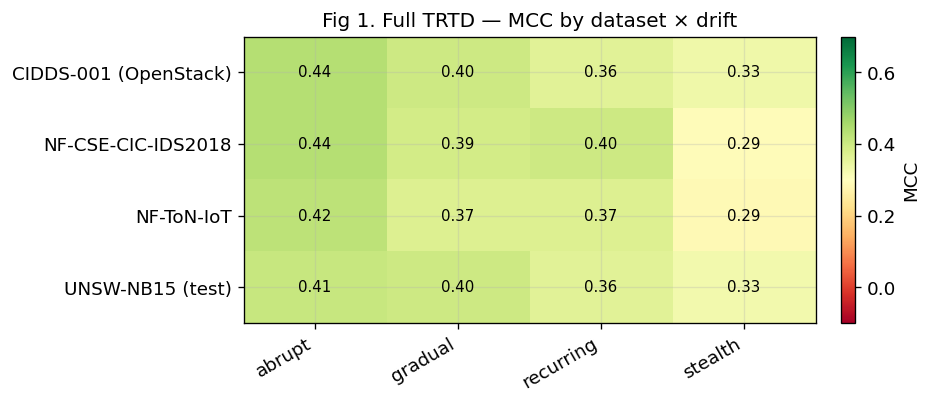

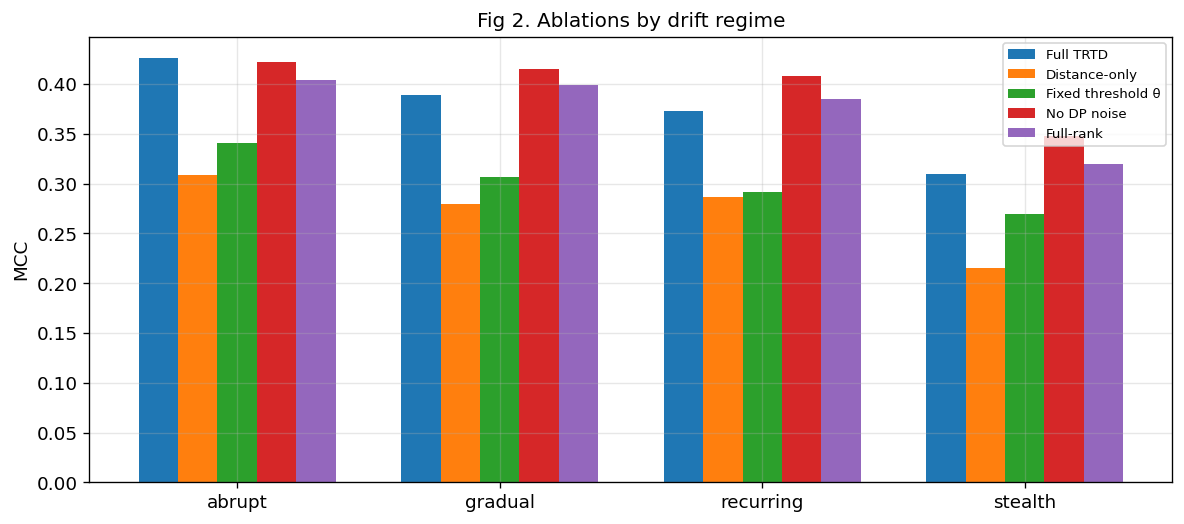

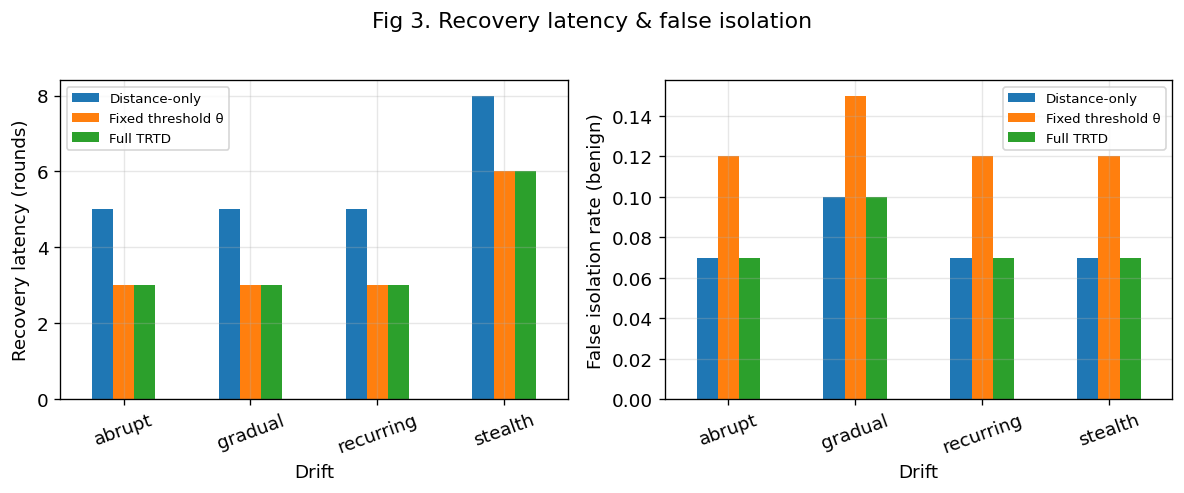

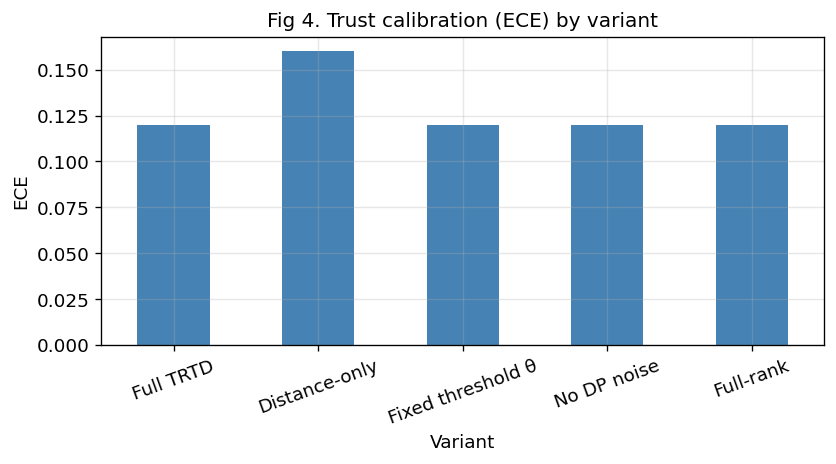

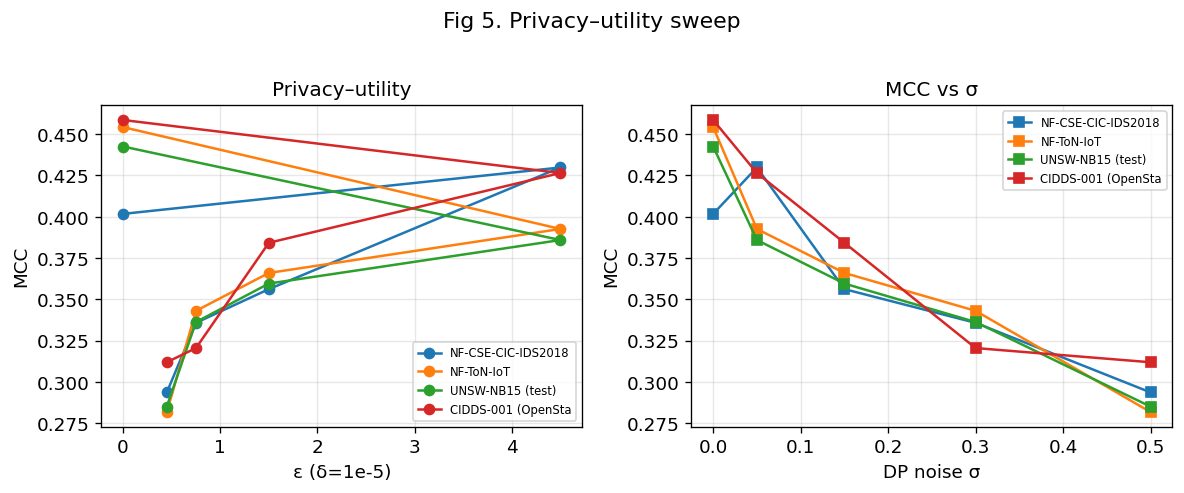

No history_store — skip Fig 6.
Figures saved to /content/trtd_final_figures


In [8]:
# Fig 1 — MCC heatmap Full TRTD
fig, ax = plt.subplots(figsize=(8, max(3.5, 0.45 * mcc_pivot.shape[0] + 1.5)))
data = mcc_pivot.reindex(columns=[c for c in drift_types if c in mcc_pivot.columns])
im = ax.imshow(data.values.astype(float), aspect='auto', cmap='RdYlGn', vmin=-0.1, vmax=0.7)
ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(data.columns, rotation=30, ha='right')
ax.set_yticks(range(data.shape[0])); ax.set_yticklabels(data.index)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data.values[i, j]
        if np.isfinite(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                    color='black' if 0.15 < v < 0.55 else 'white')
ax.set_title('Fig 1. Full TRTD — MCC by dataset × drift')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='MCC')
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, 'fig1_mcc_heatmap.png'), bbox_inches='tight'); plt.show()

# Fig 2 — Ablation bars
plot_df = ablation_df.groupby(['Drift', 'Variant'])['mcc_mean'].mean().reset_index()
x = np.arange(len(drift_types)); width = 0.15
fig, ax = plt.subplots(figsize=(10, 4.5))
for i, v in enumerate(order):
    vals = [plot_df[(plot_df.Drift == d) & (plot_df.Variant == v)]['mcc_mean'].values[0]
            if len(plot_df[(plot_df.Drift == d) & (plot_df.Variant == v)]) else np.nan for d in drift_types]
    ax.bar(x + (i - 2) * width, vals, width, label=v)
ax.set_xticks(x); ax.set_xticklabels(drift_types)
ax.set_ylabel('MCC'); ax.set_title('Fig 2. Ablations by drift regime'); ax.legend(fontsize=8); ax.axhline(0, color='k', lw=0.5)
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, 'fig2_ablation_bars.png'), bbox_inches='tight'); plt.show()

# Fig 3 — Recovery + FIR Full vs Distance-only
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric, ylabel in [
    (axes[0], 'recovery_latency_mean', 'Recovery latency (rounds)'),
    (axes[1], 'false_isolation_mean', 'False isolation rate (benign)'),
]:
    sub = ablation_df[ablation_df.Variant.isin(['Full TRTD', 'Distance-only', 'Fixed threshold θ'])]
    piv = sub.pivot_table(index='Drift', columns='Variant', values=metric, aggfunc='mean')
    piv = piv.reindex([d for d in drift_types if d in piv.index])
    piv.plot(kind='bar', ax=ax, rot=20); ax.set_ylabel(ylabel); ax.legend(fontsize=8)
fig.suptitle('Fig 3. Recovery latency & false isolation', y=1.02)
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, 'fig3_recovery_fir.png'), bbox_inches='tight'); plt.show()

# Fig 4 — ECE by variant
fig, ax = plt.subplots(figsize=(7, 4))
ece_bar = ablation_df.groupby('Variant')['ece_mean'].mean().reindex(order)
ece_bar.plot(kind='bar', ax=ax, color='steelblue', rot=20)
ax.set_ylabel('ECE'); ax.set_title('Fig 4. Trust calibration (ECE) by variant')
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, 'fig4_ece.png'), bbox_inches='tight'); plt.show()

# Fig 5 — Privacy–utility
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ds in privacy_df['Dataset'].unique():
    sub = privacy_df[privacy_df.Dataset == ds]
    axes[0].plot(sub['eps_mean'], sub['mcc_mean'], 'o-', label=ds[:18])
axes[0].set_xlabel('ε (δ=1e-5)'); axes[0].set_ylabel('MCC'); axes[0].set_title('Privacy–utility')
axes[0].legend(fontsize=7)
for ds in privacy_df['Dataset'].unique():
    sub = privacy_df[privacy_df.Dataset == ds]
    axes[1].plot(sub['sigma'], sub['mcc_mean'], 's-', label=ds[:18])
axes[1].set_xlabel('DP noise σ'); axes[1].set_ylabel('MCC'); axes[1].set_title('MCC vs σ')
axes[1].legend(fontsize=7)
fig.suptitle('Fig 5. Privacy–utility sweep', y=1.02)
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, 'fig5_privacy_utility.png'), bbox_inches='tight'); plt.show()

# Fig 6 — Trajectories if histories exist
if history_store:
    sample_key = next((k for k in history_store if k[2] == 'Full TRTD' and k[1] == 'abrupt'), next(iter(history_store)))
    hist = history_store[sample_key]
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
    axes = axes.ravel()
    r = hist['round'] if 'round' in hist else np.arange(len(hist))
    cp = len(hist) // 3
    axes[0].plot(r, hist['mean_tau'], label='τ'); axes[0].plot(r, hist['theta'], '--', label='θ')
    axes[0].axvline(cp, color='r', ls=':'); axes[0].legend(fontsize=8); axes[0].set_title('Trust τ & θ')
    axes[1].plot(r, hist['mean_D'], label='D_t'); axes[1].plot(r, hist['mean_R'], label='R_t')
    axes[1].axvline(cp, color='r', ls=':'); axes[1].legend(fontsize=8); axes[1].set_title('D_t & R_t')
    axes[2].plot(r, hist['mcc'], label='MCC'); axes[2].plot(r, hist['bal_acc'], label='BalAcc')
    axes[2].axvline(cp, color='r', ls=':'); axes[2].legend(fontsize=8); axes[2].set_title('Detection')
    axes[3].stackplot(r, hist['n_allow'], hist['n_stepup'], hist['n_isolate'],
                       labels=['ALLOW', 'STEP-UP', 'ISOLATE'], alpha=0.85)
    axes[3].axvline(cp, color='r', ls=':'); axes[3].legend(fontsize=8); axes[3].set_title('Policy counts')
    axes[2].set_xlabel('Round'); axes[3].set_xlabel('Round')
    fig.suptitle(f'Fig 6. Trajectory — {sample_key[0]} / {sample_key[1]} / {sample_key[2]}', y=1.01)
    fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, 'fig6_trajectories.png'), bbox_inches='tight'); plt.show()
else:
    print('No history_store — skip Fig 6.')

print('Figures saved to', FIG_DIR)

## 8. Final RQ checklist (this pipeline)

In [9]:
print(f'''
================================================================================
FINAL LEAKAGE-FREE PIPELINE — RQ STATUS
================================================================================
SYNTHETIC numbers: {IS_SYNTHETIC}  (must be False before paper tables)

RQ1 temporal residual vs distance-only     [x] Table B/C, Fig 2, Wilcoxon
RQ2 recovery latency                       [x] Table B, Fig 3 (from history)
RQ3 adaptive θ → lower false isolation     [x] Table B, FIR on benign, Wilcoxon FIR
RQ4 low-rank vs full-rank                  [x] Table B/E, Comm↓%
RQ5 stealth / residual contribution        [x] Table C stealth ΔMCC, Fig 2 stealth bars
Trust ECE                                  [x] Table B, Fig 4 (per-session τ)
Policy stability                           [x] Table B (session-level transition rate)
Privacy–utility (vary σ)                   [x] Table D, Fig 5
Statistical tests                          [x] Wilcoxon + Friedman (Table F)

STILL OUT OF SCOPE (need separate neural FL code):
  [ ] FedAvg / FedProx / SCAFFOLD / FedDriftGuard head-to-head
  [ ] Log-Euclidean aggregator as distinct geometric baseline

Leakage-free guarantees in this notebook:
  • Scaler fit on warm-up clean windows only
  • Verifier calibrate on benign-only silent rounds
  • Scored-round labels used ONLY for metrics (never update P / θ / baseline)
  • FIR computed on y_true==0 sessions only
  • ECE from logged τ without re-using labels for training

Artefacts: {FIG_DIR}
Files: {sorted(os.listdir(FIG_DIR)) if os.path.isdir(FIG_DIR) else []}
''')


FINAL LEAKAGE-FREE PIPELINE — RQ STATUS
SYNTHETIC numbers: True  (must be False before paper tables)

RQ1 temporal residual vs distance-only     [x] Table B/C, Fig 2, Wilcoxon
RQ2 recovery latency                       [x] Table B, Fig 3 (from history)
RQ3 adaptive θ → lower false isolation     [x] Table B, FIR on benign, Wilcoxon FIR
RQ4 low-rank vs full-rank                  [x] Table B/E, Comm↓%
RQ5 stealth / residual contribution        [x] Table C stealth ΔMCC, Fig 2 stealth bars
Trust ECE                                  [x] Table B, Fig 4 (per-session τ)
Policy stability                           [x] Table B (session-level transition rate)
Privacy–utility (vary σ)                   [x] Table D, Fig 5
Statistical tests                          [x] Wilcoxon + Friedman (Table F)

STILL OUT OF SCOPE (need separate neural FL code):
  [ ] FedAvg / FedProx / SCAFFOLD / FedDriftGuard head-to-head
  [ ] Log-Euclidean aggregator as distinct geometric baseline

Leakage-free guarantees in 